In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

In [3]:
df= pd.read_csv("spam_dataset.csv")
df

,message_content,is_spam
0,"Hello Lonnie,\n\nJust wanted to touch base reg...",0
1,"Congratulations, you've won a prize! Call us n...",1
2,You have been pre-approved for a credit card w...,1
3,"Limited time offer, act now! Only a few spots ...",1
4,Your loan has been approved! Transfer funds to...,1
...,...,...
995,"Hello Virginia,\n\nIt was great to catch up wi...",0
996,Final notice: Claim your inheritance from a di...,1
997,Hot singles in your area want to chat! Contact...,1
998,Your loan has been approved! Transfer funds to...,1


In [4]:
df.shape

(1000, 2)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   message_content  1000 non-null   object
 1   is_spam          1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


In [6]:
df.duplicated().sum()

np.int64(323)

In [7]:
df= df.drop_duplicates()

In [8]:
df.shape

(677, 2)

In [9]:
df.isnull().sum()

message_content    0
is_spam            0
dtype: int64

In [10]:
# CHECK CLASS DISTRIBUTION FIRST
print("Class distribution:")
print(df['is_spam'].value_counts())
print(f"Spam ratio: {df['is_spam'].mean():.2%}")

Class distribution:
is_spam
0    500
1    177
Name: count, dtype: int64
Spam ratio: 26.14%


In [11]:
df['message_content'][0]

'Hello Lonnie,\n\nJust wanted to touch base regarding our project’s next steps. Please find the details below. Information material statement power suddenly summer usually. Serious responsibility before new success each.\n\nKind regards,\nTerry Griffin\n\nPlease find attached the updated project plan. Let me know if you have any questions.\n\nIf you have any questions, please feel free to reach out.'

In [12]:
df['message_content']= df['message_content'].replace("\n", "")

C:\Users\User\AppData\Local\Temp\ipykernel_13072\3163503648.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['message_content']= df['message_content'].replace("\n", "")


In [13]:
df['message_content'][0]

'Hello Lonnie,\n\nJust wanted to touch base regarding our project’s next steps. Please find the details below. Information material statement power suddenly summer usually. Serious responsibility before new success each.\n\nKind regards,\nTerry Griffin\n\nPlease find attached the updated project plan. Let me know if you have any questions.\n\nIf you have any questions, please feel free to reach out.'

In [14]:
# CHECK CLASS DISTRIBUTION FIRST
print("Class distribution:")
print(df['is_spam'].value_counts())
print(f"Spam ratio: {df['is_spam'].mean():.2%}")

Class distribution:
is_spam
0    500
1    177
Name: count, dtype: int64
Spam ratio: 26.14%


In [18]:
#TF-IDF VECTORIZATION
tfidf = TfidfVectorizer(
    min_df=2,          # ignore very rare terms
    max_df=0.95,       # ignore overly common terms
    sublinear_tf=True  # apply log normalization
)
X = tfidf.fit_transform(df['message_content'].values.astype('U'))
y = df['is_spam'].values
print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (677, 1436)


In [19]:
#SPLIT DATA
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [20]:
# Option 1: ComplementNB (designed for imbalanced text classification)
model = ComplementNB()
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,norm,False


In [21]:
y_proba = model.predict_proba(X_test)[:, 1]  # probability of spam

In [22]:
# Find threshold that balances precision/recall
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
# Pick threshold closest to top-left corner of ROC curve
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.3f}")

y_pred_default   = (y_proba >= 0.5).astype(int)
y_pred_optimized = (y_proba >= optimal_threshold).astype(int)

Optimal threshold: 1.000


In [23]:
# COMPARE RESULTS
print("\n--- Default threshold (0.5) ---")
print(confusion_matrix(y_test, y_pred_default))
print(classification_report(y_test, y_pred_default, target_names=['Not Spam', 'Spam']))

print(f"\n--- Optimized threshold ({optimal_threshold:.3f}) ---")
print(confusion_matrix(y_test, y_pred_optimized))
print(classification_report(y_test, y_pred_optimized, target_names=['Not Spam', 'Spam']))



--- Default threshold (0.5) ---
[[100   0]
 [  0  36]]
              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00       100
        Spam       1.00      1.00      1.00        36

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136


--- Optimized threshold (1.000) ---
[[100   0]
 [  0  36]]
              precision    recall  f1-score   support

    Not Spam       1.00      1.00      1.00       100
        Spam       1.00      1.00      1.00        36

    accuracy                           1.00       136
   macro avg       1.00      1.00      1.00       136
weighted avg       1.00      1.00      1.00       136



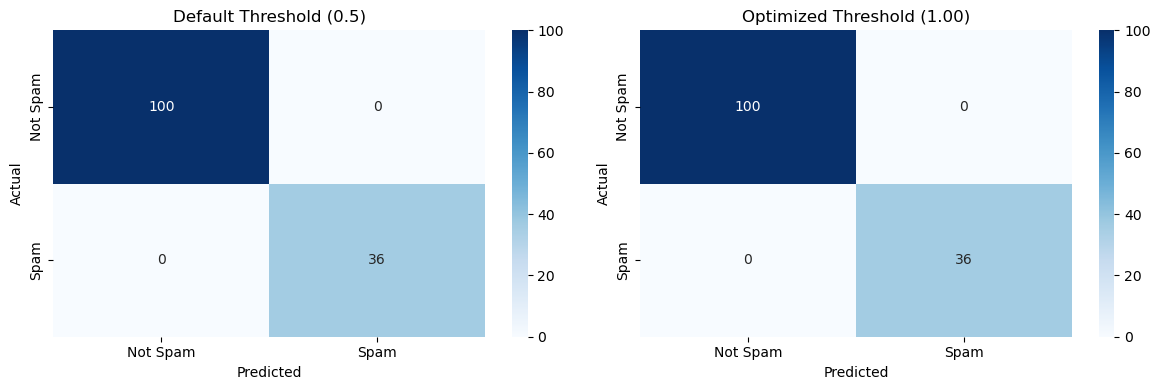

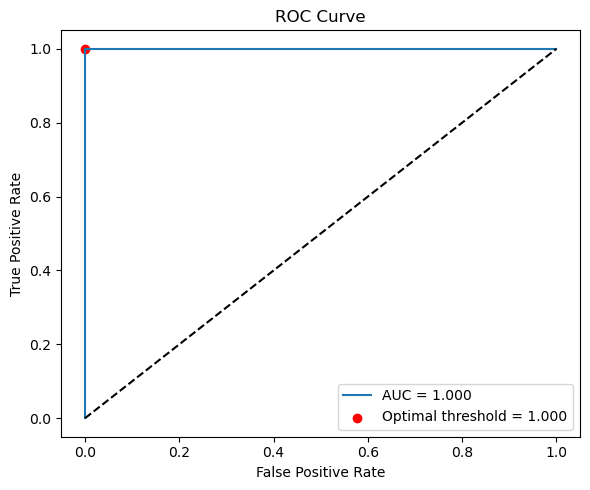

In [24]:
# VISUALIZE BOTH CONFUSION MATRICES
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title in zip(
    axes,
    [y_pred_default, y_pred_optimized],
    ['Default Threshold (0.5)', f'Optimized Threshold ({optimal_threshold:.2f})']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Spam', 'Spam'],
                yticklabels=['Not Spam', 'Spam'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

plt.tight_layout()
plt.show()

# ── ROC CURVE ─────────────────────────────────────────
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', 
            label=f'Optimal threshold = {optimal_threshold:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
# PREDICT FROM USER INPUT
def predict_message(message, model, tfidf):
    # Transform the input using the already-fitted tfidf
    message_transformed = tfidf.transform([message])
    
    # Get prediction and probability
    prediction = model.predict(message_transformed)[0]
    probability = model.predict_proba(message_transformed)[0]
    
    spam_prob  = probability[1] * 100
    not_spam_prob   = probability[0] * 100
    
    print("\n" + "="*50)
    print(f"Message: {message}")
    print(f"{'='*50}")
    print(f"Prediction : {'🚨 SPAM' if prediction == 1 else '✅  Not Spam'}")
    print(f"Spam  Prob : {spam_prob:.2f}%")
    print(f"Not spam   Prob : {not_spam_prob:.2f}%")
    print("="*50)
    
    return prediction, spam_prob

In [30]:
# SINGLE MESSAGE TEST
user_message = input("Enter a message to check: ")
predict_message(user_message, model, tfidf)

Enter a message to check:  hi hi hi



Message: hi hi hi
Prediction : ✅  Not Spam
Spam  Prob : 14.47%
Not spam   Prob : 85.53%


(np.int64(0), np.float64(14.471801163839185))

In [28]:
import pickle

#SAVE MODEL AND VECTORIZER
with open('emailbody.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('emailbody_tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!
